In [7]:
import os
import shutil
import zipfile
import warnings
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive

warnings.filterwarnings('ignore')
print("Imports successful.")


Imports successful.


In [8]:
GDRIVE_ZIP_PATH = '/content/drive/MyDrive/AD_Dataset_compressed.zip'
LOCAL_ZIP_PATH = '/content/Data.zip'
LOCAL_UNZIP_DIR = '/content/Data'
DATA_DIR = '/content/Data/AD Datasets/Data'

IMG_SIZE = (224, 224)
BATCH_SIZE = 128
NUM_CLASSES = 4
EPOCHS = 50
LEARNING_RATE = 1e-4
SEED = 42
BEST_MODEL_SAVE_PATH = 'resnet50_best_model.keras'
AUTOTUNE = tf.data.AUTOTUNE

print("Configuration parameters set.")


Configuration parameters set.


In [9]:
# Mount Google Drive & Extract Dataset

drive.mount('/content/drive', force_remount=True)

if not os.path.exists(GDRIVE_ZIP_PATH):
    raise FileNotFoundError(f"Zip file not found at {GDRIVE_ZIP_PATH}")

shutil.copyfile(GDRIVE_ZIP_PATH, LOCAL_ZIP_PATH)

if os.path.exists(LOCAL_UNZIP_DIR):
    shutil.rmtree(LOCAL_UNZIP_DIR)
os.makedirs(LOCAL_UNZIP_DIR)

with zipfile.ZipFile(LOCAL_ZIP_PATH, 'r') as z:
    z.extractall(LOCAL_UNZIP_DIR)

if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(f"Expected data directory not found at {DATA_DIR}")

print("Dataset successfully extracted.")


Mounted at /content/drive
Dataset successfully extracted.


In [10]:
# Load Dataset & Split (80/10/10)


full_dataset = image_dataset_from_directory(
    DATA_DIR,
    label_mode='int',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

class_names = full_dataset.class_names
print("Classes:", class_names)

total_batches = tf.data.experimental.cardinality(full_dataset).numpy()
train_batches = int(total_batches * 0.8)
val_batches = int(total_batches * 0.1)
test_batches = total_batches - train_batches - val_batches

if val_batches == 0 and total_batches > train_batches:
    val_batches = 1
if test_batches == 0 and total_batches > train_batches + val_batches:
    test_batches = 1
train_batches = total_batches - val_batches - test_batches

train_dataset = full_dataset.take(train_batches)
val_and_test = full_dataset.skip(train_batches)
val_dataset = val_and_test.take(val_batches)
test_dataset = val_and_test.skip(val_batches)

print(f"Total batches: {total_batches}; train: {train_batches}; val: {val_batches}; test: {test_batches}")


Found 86437 files belonging to 4 classes.
Classes: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']
Total batches: 676; train: 540; val: 67; test: 69


In [11]:
# Class Weights, Caching, and Augmentation


train_label_list = []
for _, lbl in train_dataset:
    train_label_list.extend(lbl.numpy())
train_label_array = np.array(train_label_list)

unique_classes = np.unique(train_label_array)
weights = compute_class_weight('balanced', classes=unique_classes, y=train_label_array)
class_weight_dict = {int(c): float(w) for c, w in zip(unique_classes, weights)}
print("Class weights:", class_weight_dict)

train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.15),
])

print("Augmentation and caching configured.")

Class weights: {0: 4.3680485338725985, 1: 45.23560209424084, 2: 0.32106426859404325, 3: 1.5764984946628957}
Augmentation and caching configured.


In [17]:
# Build Transfer Learning Model (ResNet50 + Focal Loss + Custom Dense Head)


import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# --- Parameters (redeclare to make this cell independent) ---
IMG_SIZE = (224, 224)
NUM_CLASSES = 4
LEARNING_RATE = 1e-4

# --- Data augmentation (must match earlier pipeline) ---
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# --- Focal Loss Implementation ---
def focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=NUM_CLASSES)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        cross_entropy = -y_true_one_hot * tf.math.log(y_pred)
        weight = alpha * tf.math.pow(1 - y_pred, gamma)
        loss_value = tf.reduce_sum(weight * cross_entropy, axis=1)
        return tf.reduce_mean(loss_value)
    return loss

# --- Build ResNet50 Base ---
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False  # freeze base for transfer learning

# --- Build Custom Head ---
inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)
x = tf.keras.applications.resnet50.preprocess_input(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dense(512, activation='relu')(x)
x = Dense(256, activation='relu')(x)
x = Dense(10, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

# --- Compile Model ---
model = Model(inputs, outputs)
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

# --- Summary ---
print("Model Summary:")
model.summary()


Model Summary:


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 224, 224,  │          0 │ input_layer_7[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_6          │ (None, 224, 224)  │          0 │ sequential_3[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_7          │ (None, 224, 224)  │          0 │ sequential_3[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_8          │ (None, 224, 224)  │          0 │ sequential_3[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_2 (Stack)     │ (None, 224, 224,  │          0 │ get_item_6[0][0], │
│                     │ 3)                │            │ get_item_7[0][0], │
│                     │                   │            │ get_item_8[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 224, 224,  │          0 │ stack_2[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_2[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1024)      │  2,098,176 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 512)       │    524,800 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 256)       │    131,328 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 10)        │      2,570 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 10)        │          0 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 4)         │         44 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,344,630 (100.50 MB)

 Trainable params: 2,756,918 (10.52 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [18]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

print("Recomputing class weights from training dataset...")

# Extract all labels from training dataset
train_labels = []
for _, labels in train_dataset:
    train_labels.extend(labels.numpy())
train_labels = np.array(train_labels)

# Compute balanced class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Map to dict for Keras
class_weight_dict_mapped = {
    int(cls): float(weight)
    for cls, weight in zip(np.unique(train_labels), class_weights_array)
}

print("Class weights computed successfully:")
print(class_weight_dict_mapped)


Recomputing class weights from training dataset...
Class weights computed successfully:
{0: 4.35374149659864, 1: 45.354330708661415, 2: 0.3210463733650416, 3: 1.578658870820391}


In [20]:
# Model Training (50 Epochs)

import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

# --- Define focal loss inline for reliability ---
def focal_loss_fn(gamma=2., alpha=0.25):
    def focal_loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_one_hot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        cross_entropy = tf.keras.losses.categorical_crossentropy(y_true_one_hot, y_pred)
        probs = tf.reduce_sum(y_true_one_hot * y_pred, axis=-1)
        focal_factor = alpha * tf.pow(1. - probs, gamma)
        return tf.reduce_mean(focal_factor * cross_entropy)
    return focal_loss

# --- Recompile the model with smaller learning rate for smoother convergence ---
optimizer = Adam(learning_rate=1e-5)
model.compile(optimizer=optimizer, loss=focal_loss_fn(), metrics=['accuracy'])

# --- Checkpoint: save only the best model based on validation accuracy ---
checkpoint = ModelCheckpoint(
    filepath=BEST_MODEL_SAVE_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

print("\n--- Starting Model Training (50 Epochs, No Early Stopping) ---")
print(f"Best model will be saved to {BEST_MODEL_SAVE_PATH}")

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    class_weight=class_weight_dict_mapped,
    callbacks=[checkpoint]
)

print("\n--- Training Complete ---")



--- Starting Model Training (50 Epochs, No Early Stopping) ---
Best model will be saved to resnet50_best_model.keras
Epoch 1/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.5075 - loss: 0.1428
Epoch 1: val_accuracy improved from -inf to 0.78696, saving model to resnet50_best_model.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.5076 - loss: 0.1428 - val_accuracy: 0.7870 - val_loss: 0.0862
Epoch 2/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.5705 - loss: 0.1164
Epoch 2: val_accuracy improved from 0.78696 to 0.79536, saving model to resnet50_best_model.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 46s 85ms/step - accuracy: 0.5705 - loss: 0.1164 - val_accuracy: 0.7954 - val_loss: 0.0794
Epoch 3/50
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.6057 - loss: 0.1088
Epoch 3: val_accuracy did not improve from 0.79536
540/540 ━━━━━━━━━━━━━━━━━━━━ 45s 83ms/step - accuracy: 0.6057 - loss: 0.1088 - val_accuracy: 0.7901 - val_loss: 0.0678
Epoch 4/50
540/540 ━

In [22]:
# Evaluate Best Model on Train/Validation/Test Sets

import tensorflow as tf
from tensorflow.keras.models import load_model

# --- Re-define focal loss exactly as used during training ---
def focal_loss_fn(gamma=2., alpha=0.25):
    def focal_loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_one_hot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        cross_entropy = tf.keras.losses.categorical_crossentropy(y_true_one_hot, y_pred)
        probs = tf.reduce_sum(y_true_one_hot * y_pred, axis=-1)
        focal_factor = alpha * tf.pow(1. - probs, gamma)
        return tf.reduce_mean(focal_factor * cross_entropy)
    return focal_loss

print(f"\nLoading best model from {BEST_MODEL_SAVE_PATH} ...")

# --- Load model with custom loss registered ---
best_model = load_model(
    BEST_MODEL_SAVE_PATH,
    custom_objects={'focal_loss': focal_loss_fn()}
)

# --- Evaluate on all datasets ---
print("\nEvaluating model performance ...")

train_loss, train_acc = best_model.evaluate(train_dataset)
val_loss, val_acc = best_model.evaluate(val_dataset)
test_loss, test_acc = best_model.evaluate(test_dataset)

print("\n--- Final Overall Performance ---")
print(f"Training Accuracy:   {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"Test Accuracy:       {test_acc:.4f} ({test_acc*100:.2f}%)")

print("\n--- Final Overall Loss ---")
print(f"Training Loss:   {train_loss:.4f}")
print(f"Validation Loss: {val_loss:.4f}")
print(f"Test Loss:       {test_loss:.4f}")



Loading best model from resnet50_best_model.keras ...

Evaluating model performance ...
540/540 ━━━━━━━━━━━━━━━━━━━━ 42s 71ms/step - accuracy: 0.8627 - loss: 0.0276
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.8565 - loss: 0.0305
69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/step - accuracy: 0.8547 - loss: 0.0299

--- Final Overall Performance ---
Training Accuracy:   0.8602 (86.02%)
Validation Accuracy: 0.8554 (85.54%)
Test Accuracy:       0.8521 (85.21%)

--- Final Overall Loss ---
Training Loss:   0.0279
Validation Loss: 0.0301
Test Loss:       0.0296



Generating predictions on the test set...
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step

--- Per-Class Metrics (Test Set) ---
                    precision    recall  f1-score   support

     Mild Dementia     0.8801    0.6188    0.7267       522
 Moderate Dementia     0.0000    0.0000    0.0000        52
      Non Demented     0.8504    0.9856    0.9130      6809
Very mild Dementia     0.8589    0.3049    0.4500      1358

          accuracy                         0.8521      8741
         macro avg     0.6473    0.4773    0.5224      8741
      weighted avg     0.8484    0.8521    0.8245      8741


Generating Confusion Matrix...


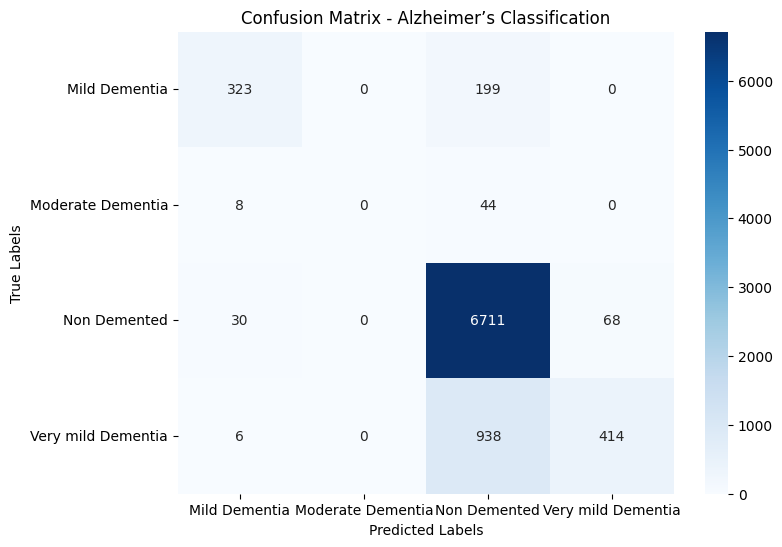

In [23]:
# Classification Report + Confusion Matrix

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# --- Get true and predicted labels from test dataset ---
print("\nGenerating predictions on the test set...")

y_true = np.concatenate([y for _, y in test_dataset], axis=0)
y_pred_probs = best_model.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

# --- Classification Report ---
print("\n--- Per-Class Metrics (Test Set) ---")
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

# --- Confusion Matrix ---
print("\nGenerating Confusion Matrix...")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - Alzheimer’s Classification")
plt.show()


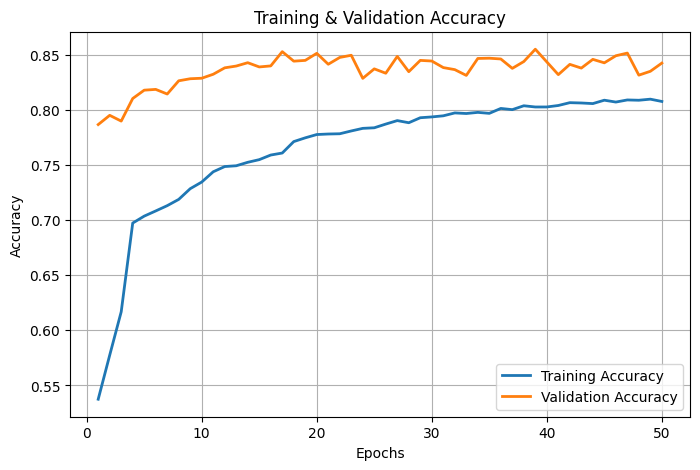

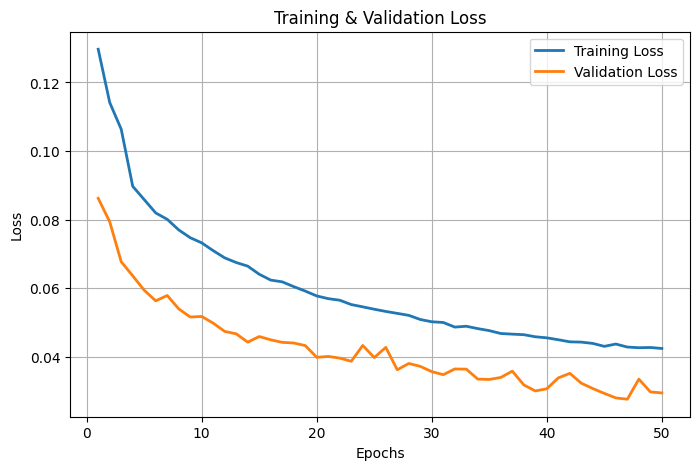

In [24]:
# Plot Learning Curves (Accuracy & Loss)


# --- Extract training history ---
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# --- Accuracy Plot ---
plt.figure(figsize=(8, 5))
plt.plot(epochs, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs, val_acc, label='Validation Accuracy', linewidth=2)
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# --- Loss Plot ---
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label='Training Loss', linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', linewidth=2)
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
